<a href="https://colab.research.google.com/github/Josiah-Kunz/MGN-Public/blob/main/examples/colab/1_basic_tools/3_fixed_boundary_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introductory example for using fixed boundary conditions.
Like the loads example, specifying fixed boundaries like this not only make for a more parsable FEM, it also helps the MGN assign the right node types.

In [1]:
%%capture

try:
    import google.colab  # noqa: F401
except ImportError:
    import ufl_legacy
    import fenics
else:
    try:
        import ufl_legacy
        import fenics
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
        import ufl_legacy
        import fenics

!apt-get install -y libglu1-mesa -q
!pip install gmsh meshio pint torch torch-geometric scikit-learn -q
!pip install meshgraphnet -q

import os
from meshgraphnet import MeshObject, Units, FixedBoundary
import matplotlib.pyplot as plt

# Get the cantilever stp file so we can create a mesh
!wget "https://raw.githubusercontent.com/Josiah-Kunz/MGN-Public/refs/heads/colab-examples/examples/local/cantilever/geometries/cantilever.stp" -O "cantilever.stp" -q


In [2]:
def main():

    # Get a mesh to load
    mesh = MeshObject("cantilever.stp", 250, units=Units.SI_MM, force_2d=True)

    # Set boundaries
    boundaries = []
    boundaries.append(FixedBoundary('left', value=(0, 0, 0), name="Fixed"))
    boundaries.append(FixedBoundary('right', value=(0, 0), components=(0, 2), name="Roller"))
    boundaries.append(FixedBoundary(
        location=lambda x, on_boundary: on_boundary and x[0] < 5000 and x[0]>1000,
        value=(0, 0, 0),
        name="Partial fix"
    ))

    # Get the color cycle
    colors = ["green", "red", "blue"]
    colorIdx = 0

    # Visualize
    fig = mesh.visualize(show=False)
    ax = fig.axes[0]
    for boundary in boundaries:
        boundary.draw_on_ax(ax, mesh, color=colors[colorIdx % len(colors)])
        colorIdx += 1
    plt.title(f"{mesh.name} Boundary Examples")
    plt.tight_layout()
    plt.show()

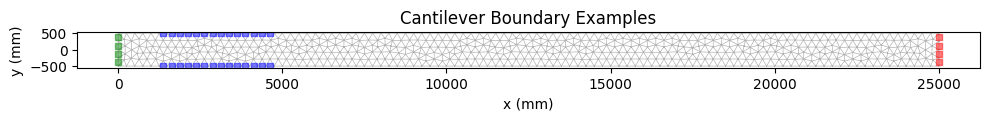

In [3]:
if __name__ == "__main__":
    main()